In [1]:
import os
import re
import numpy as np
import time
import random
import pandas as pd
import glob
import shutil
import seaborn as sns
import itertools
import math
from pathlib import Path
import json
from copy import deepcopy
from dataclasses import dataclass
from types import SimpleNamespace
from typing import Tuple, Dict, Union, Iterable, List

from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from sklearn.metrics import confusion_matrix
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import autocatalytic_cores_lib as ac
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import newton_krylov
from scipy.optimize import broyden1
from scipy.optimize import anderson
from scipy.optimize._nonlin import NoConvergence
from sympy import symbols, Matrix, diff, lambdify
from scipy.linalg import eigvals
from numpy.linalg import svd
from scipy.optimize import linprog
from scipy.sparse import csr_matrix
from scipy.sparse import bmat
from scipy.sparse.csgraph import connected_components
from scipy.linalg import eigh
from scipy.optimize import fsolve
from textwrap import dedent
import networkx as nx   
from matplotlib import animation

In [2]:
class Neumann(object):

    """
    This class describes the Generalized von Neumann growth model as it was
    discussed in Kemeny et al. (1956, ECTA) and Gale (1960, Chapter 9.5):

    Let:
    n ... number of goods
    m ... number of activities
    A ... input matrix is m-by-n
        a_{i,j} - amount of good j consumed by activity i
    B ... output matrix is m-by-n
        b_{i,j} - amount of good j produced by activity i

    x ... intensity vector (m-vector) with non-negative entries
        x'B - the vector of goods produced
        x'A - the vector of goods consumed
    p ... price vector (n-vector) with non-negative entries
        Bp - the revenue vector for every activity
        Ap - the cost of each activity

    Both A and B have non-negative entries. Moreover, we assume that
    (1) Assumption I (every good which is consumed is also produced):
        for all j, b_{.,j} > 0, i.e. at least one entry is strictly positive
    (2) Assumption II (no free lunch):
        for all i, a_{i,.} > 0, i.e. at least one entry is strictly positive

    Parameters
    ----------
    A : array_like or scalar(float)
        Part of the state transition equation.  It should be `n x n`
    B : array_like or scalar(float)
        Part of the state transition equation.  It should be `n x k`
    """

    def __init__(self, A, B):

        self.A, self.B = list(map(self.convert, (A, B)))
        self.m, self.n = self.A.shape

        # Check if (A, B) satisfy the basic assumptions
        assert self.A.shape == self.B.shape, 'The input and output matrices \
              must have the same dimensions!'
        assert (self.A >= 0).all() and (self.B >= 0).all(), 'The input and \
              output matrices must have only non-negative entries!'

        # (1) Check whether Assumption I is satisfied:
        if (np.sum(B, 0) <= 0).any():
            self.AI = False
        else:
            self.AI = True

        # (2) Check whether Assumption II is satisfied:
        if (np.sum(A, 1) <= 0).any():
            self.AII = False
        else:
            self.AII = True

    def __repr__(self):
        return self.__str__()

    def __str__(self):

        me = """
        Generalized von Neumann expanding model:
          - number of goods          : {n}
          - number of activities     : {m}

        Assumptions:
          - AI:  every column of B has a positive entry    : {AI}
          - AII: every row of A has a positive entry       : {AII}

        """
        # Irreducible                                       : {irr}
        return dedent(me.format(n=self.n, m=self.m,
                                AI=self.AI, AII=self.AII))

    def convert(self, x):
        """
        Convert array_like objects (lists of lists, floats, etc.) into
        well-formed 2D NumPy arrays
        """
        return np.atleast_2d(np.asarray(x))


    def bounds(self):
        """
        Calculate the trivial upper and lower bounds for alpha (expansion rate)
        and beta (interest factor). See the proof of Theorem 9.8 in Gale (1960)
        """

        n, m = self.n, self.m
        A, B = self.A, self.B

        f = lambda α: ((B - α * A) @ np.ones((n, 1))).max()
        g = lambda β: (np.ones((1, m)) @ (B - β * A)).min()

        UB = fsolve(f, 1).item()  # Upper bound for α, β
        LB = fsolve(g, 2).item()  # Lower bound for α, β

        return LB, UB


    def zerosum(self, γ, dual=False):
        """
        Given gamma, calculate the value and optimal strategies of a
        two-player zero-sum game given by the matrix

                M(gamma) = B - gamma * A

        Row player maximizing, column player minimizing

        Zero-sum game as an LP (primal --> α)

            max (0', 1) @ (x', v)
            subject to
            [-M', ones(n, 1)] @ (x', v)' <= 0
            (x', v) @ (ones(m, 1), 0) = 1
            (x', v) >= (0', -inf)

        Zero-sum game as an LP (dual --> beta)

            min (0', 1) @ (p', u)
            subject to
            [M, -ones(m, 1)] @ (p', u)' <= 0
            (p', u) @ (ones(n, 1), 0) = 1
            (p', u) >= (0', -inf)

        Outputs:
        --------
        value: scalar
            value of the zero-sum game

        strategy: vector
            if dual = False, it is the intensity vector,
            if dual = True, it is the price vector
        """

        A, B, n, m = self.A, self.B, self.n, self.m
        M = B - γ * A

        if dual == False:
            # Solve the primal LP (for details see the description)
            # (1) Define the problem for v as a maximization (linprog minimizes)
            c = np.hstack([np.zeros(m), -1])

            # (2) Add constraints :
            # ... non-negativity constraints
            bounds = tuple(m * [(0, None)] + [(None, None)])
            # ... inequality constraints
            A_iq = np.hstack([-M.T, np.ones((n, 1))])
            b_iq = np.zeros((n, 1))
            # ... normalization
            A_eq = np.hstack([np.ones(m), 0]).reshape(1, m + 1)
            b_eq = 1

            res = linprog(c, A_ub=A_iq, b_ub=b_iq, A_eq=A_eq, b_eq=b_eq,
                          bounds=bounds)

        else:
            # Solve the dual LP (for details see the description)
            # (1) Define the problem for v as a maximization (linprog minimizes)
            c = np.hstack([np.zeros(n), 1])

            # (2) Add constraints :
            # ... non-negativity constraints
            bounds = tuple(n * [(0, None)] + [(None, None)])
            # ... inequality constraints
            A_iq = np.hstack([M, -np.ones((m, 1))])
            b_iq = np.zeros((m, 1))
            # ... normalization
            A_eq = np.hstack([np.ones(n), 0]).reshape(1, n + 1)
            b_eq = 1

            res = linprog(c, A_ub=A_iq, b_ub=b_iq, A_eq=A_eq, b_eq=b_eq,
                          bounds=bounds)

        if res.status != 0 or res.x is None:
            # LP infeasible or error
            return np.nan, None

        # Pull out the required quantities
        value = res.x[-1]
        strategy = res.x[:-1]

        return value, strategy


    def expansion(self, tol=1e-8, maxit=1000):
        """
        The algorithm used here is described in Hamburger-Thompson-Weil
        (1967, ECTA). It is based on a simple bisection argument and utilizes
        the idea that for a given γ (= α or β), the matrix "M = B - γ * A"
        defines a two-player zero-sum game, where the optimal strategies are
        the (normalized) intensity and price vector.

        Outputs:
        --------
        alpha: scalar
            optimal expansion rate
        """

        LB, UB = self.bounds()

        for iter in range(maxit):

            γ = (LB + UB) / 2
            ZS = self.zerosum(γ=γ, dual=False)
            V = ZS[0]     # value of the game with γ

            if V >= 0:
                LB = γ
            else:
                UB = γ

            if abs(UB - LB) < tol:
                γ = (UB + LB) / 2
                x = self.zerosum(γ=γ)[1]
                p = self.zerosum(γ=γ, dual=True)[1]
                break

        return γ, x, p

    def interest(self, tol=1e-8, maxit=1000):
        """
        The algorithm used here is described in Hamburger-Thompson-Weil
        (1967, ECTA). It is based on a simple bisection argument and utilizes
        the idea that for a given gamma (= alpha or beta),
        the matrix "M = B - γ * A" defines a two-player zero-sum game,
        where the optimal strategies are the (normalized) intensity and price
        vector

        Outputs:
        --------
        beta: scalar
            optimal interest rate
        """

        LB, UB = self.bounds()

        for iter in range(maxit):
            γ = (LB + UB) / 2
            ZS = self.zerosum(γ=γ, dual=True)
            V = ZS[0]

            if V > 0:
                LB = γ
            else:
                UB = γ

            if abs(UB - LB) < tol:
                γ = (UB + LB) / 2
                p = self.zerosum(γ=γ, dual=True)[1]
                x = self.zerosum(γ=γ)[1]
                break

        return γ, x, p

def compute_von_neumann_alpha_beta(S_plus, S_minus, tol=1e-8):
    """
    Compute von Neumann alpha (expansion), beta (interest),
    and the optimal normalized flows for both problems.

    Returns:
    --------
    alpha : Optimal expansion rate.
    beta : Optimal interest rate.
    x_alpha : Optimal intensity vector (normalized flow) for expansion.
    p_alpha : Optimal price vector for expansion.
    x_beta : Optimal intensity vector (normalized flow) for interest.
    p_beta : Optimal price vector for interest.
    """
    
    A = S_minus.T
    B = S_plus.T
    model = Neumann(A, B)

    # alpha
    alpha, x_alpha, p_alpha = model.expansion(tol=tol)

    # beta
    beta, x_beta, p_beta  = model.interest(tol=tol)

    return alpha, beta, x_alpha, p_alpha, x_beta, p_beta

In [3]:
def _collect_blocks_by_line(txt_path: str) -> Dict[int, Dict[str, List[str]]]:
    """
    Collect lines under each 'S_plus:' and 'S_minus:' for every '# Realization k'.
    - Uses .strip() to detect headers/labels (robust to leading spaces / CRLF).
    - Keeps all lines (including blanks); the parser will ignore blanks later.
    """
    blocks: Dict[int, Dict[str, List[str]]] = {}
    cur_id: int | None = None
    cur_label: str | None = None

    with open(txt_path, "rb") as fb:
        raw = fb.read()
    # Try utf-8 first; fallback to latin-1 if needed
    try:
        text = raw.decode("utf-8")
    except UnicodeDecodeError:
        text = raw.decode("latin-1")

    for raw_line in text.splitlines():
        # Preserve original for storage; but use stripped for control flow
        orig = raw_line.rstrip("\r")  # drop only trailing CR if present
        s = orig.strip()

        # New realization header? (after stripping)
        m = re.match(r'^#\s*Realization\s+(\d+)$', s)
        if m:
            cur_id = int(m.group(1))
            blocks.setdefault(cur_id, {"S_plus": [], "S_minus": []})
            cur_label = None
            continue

        # New section labels (after stripping)
        if s == "S_plus:":
            cur_label = "S_plus"
            continue
        if s == "S_minus:":
            cur_label = "S_minus"
            continue

        # Accumulate table body lines
        if cur_id is not None and cur_label is not None:
            blocks[cur_id][cur_label].append(orig)  # keep as-is (incl. blanks)

    return blocks

def _parse_df_from_lines(lines: List[str]) -> pd.DataFrame:
    """
    Parse a pandas.to_string()-style table lines:
      header: '    1  2  3 ...'
      rows:   '1  0  1  0 ...'
    Ignores completely blank lines.
    """
    # Drop purely blank lines
    lines = [ln for ln in lines if ln.strip() != ""]
    if not lines:
        return pd.DataFrame()

    # First non-blank is header
    header_tokens = lines[0].split()
    try:
        cols = [int(tok) for tok in header_tokens]
    except ValueError:
        raise ValueError(f"Header row not purely integers: {lines[0]!r}")

    ncols = len(cols)
    data = []
    idx = []

    # Remaining lines are data rows
    for ln in lines[1:]:
        toks = ln.split()
        if not toks:
            continue
        # Expect 1 index token + ncols data tokens
        if len(toks) < 1 + ncols:
            # If you see this, your text rows got truncated
            raise ValueError(
                f"Row has {len(toks)} tokens; expected {1+ncols}: {ln!r}"
            )
        try:
            row_idx = int(toks[0])
            row_vals = [int(x) for x in toks[1:1+ncols]]
        except ValueError as e:
            raise ValueError(f"Non-integer token in row: {ln!r}") from e

        if len(row_vals) != ncols:
            raise ValueError(f"Bad row width: {ln!r}")

        idx.append(row_idx)
        data.append(row_vals)

    if not data:
        # Header-only => empty matrix (0 rows). This can happen if what was written had shape (0, ncols).
        return pd.DataFrame(columns=cols, dtype=int)

    df = pd.DataFrame(data, index=idx, columns=cols)
    return df.astype(int)


def list_realizations(txt_path: str) -> Iterable[int]:
    blocks = _collect_blocks_by_line(txt_path)
    return sorted(blocks.keys())

def _parse_ndarray_from_lines(lines: List[str]) -> np.ndarray:
    """Parse a table printed by DataFrame.to_string() into a numpy ndarray[int]."""
    # detlete empty line
    lines = [ln for ln in lines if ln.strip() != ""]
    if not lines:
        return np.empty((0, 0), dtype=int)

    # The first line is the column number
    header_tokens = lines[0].split()
    try:
        ncols = len([int(tok) for tok in header_tokens])
    except ValueError:
        raise ValueError(f"Header row not purely integers: {lines[0]!r}")

    data_rows: List[List[int]] = []
    for ln in lines[1:]:
        toks = ln.split()
        if not toks:
            continue
        if len(toks) < 1 + ncols:
            raise ValueError(f"Row has {len(toks)} tokens; expected {1+ncols}: {ln!r}")
        try:
            # toks[0] is the row index, discard it; the following ncols elements are the values.
            row_vals = [int(x) for x in toks[1:1+ncols]]
        except ValueError:
            raise ValueError(f"Non-integer token in row: {ln!r}")
        if len(row_vals) != ncols:
            raise ValueError(f"Bad row width: {ln!r}")
        data_rows.append(row_vals)

    if not data_rows:
        return np.empty((0, ncols), dtype=int)

    return np.array(data_rows, dtype=int)

def load_realization(
    txt_path: str,
    realization_id: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (S_plus, S_minus) as ndarrays[int]."""
    blocks = _collect_blocks_by_line(txt_path)
    if realization_id not in blocks:
        raise KeyError(f"Realization {realization_id} not found. Available: {sorted(blocks.keys())}")

    plus_lines  = blocks[realization_id].get("S_plus", [])
    minus_lines = blocks[realization_id].get("S_minus", [])

    S_plus  = _parse_ndarray_from_lines(plus_lines)
    S_minus = _parse_ndarray_from_lines(minus_lines)
    return S_plus, S_minus



In [4]:
import algorithm_1 as algo1
import auxiliary_functions as aux
from autocatalytic_cores_lib import *

In [5]:
def auto(S_tot, output_dir):

    Excelfile = os.path.join(output_dir, f"Cores.xlsx")
    histogramfile = os.path.join(output_dir, f"CoresHistogram.png")
    txtfile = os.path.join(output_dir, f"Cores.txt")
    
    df = ac.computeAutocatalyticCores(S_tot, Excelfile, histogramfile, txtfile)
    return


S_plus (realization 1) shape: (5, 12)
[[1 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 1 0 0 1 0 1 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 0 1 0 0 0]]

S_minus (realization 1) shape: (5, 12)
[[0 0 1 0 0 1 0 0 0 0 1 0]
 [0 1 0 0 1 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 1 0 1 1 1 1 0 0]
 [1 0 0 1 0 1 0 0 0 0 0 1]]

S_tot (realization 1)
[[ 1  1 -1  0  1 -1  0  0  0  1 -1  0]
 [ 0 -1  1  0 -1  1 -1  1  0  0  1  0]
 [ 0  0 -1  0  0  1  0  0  0  0  0  1]
 [-1 -1  0  1 -1  0 -1 -1 -1 -1  0  0]
 [-1  1  1 -1  0 -1  1  0  1  0  0 -1]]

Network alpha = 0.999999996806894
Network beta = 0.999999996806894


# Species: 5, # Reactions: 12
Generating Autocatalytic Cores...
Autocatalytic Cores: 5


# Autocatalytic Cores: 9
Total Computation Time: 0.07 secs.
Results saved to results_order2/realization1/Cores.xlsx


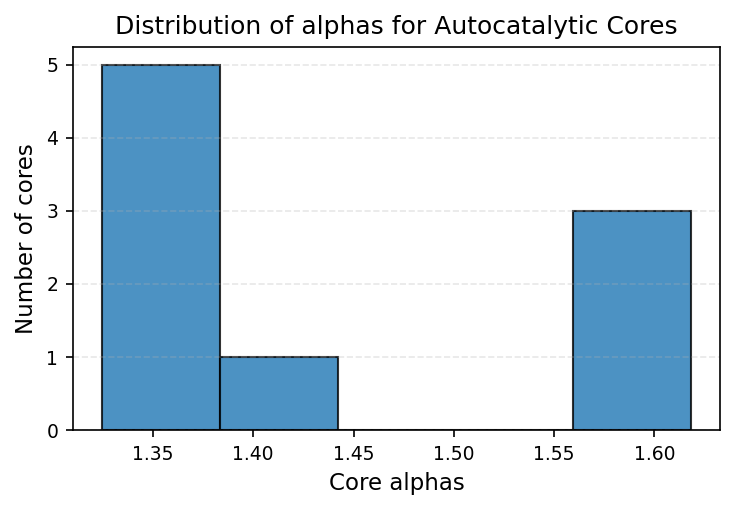

In [9]:
if __name__ == "__main__":
    #base_folder = 'distri_order2'
    #fmt_path = os.path.join(base_folder, 'stoichiometries_formatted.txt')
    base_folder = 'results_order2'
    fmt_path = os.path.join(base_folder, 'stoichiometries_formatted.txt')

    realization_id = 1
    realization_folder = os.path.join(base_folder, f"realization{realization_id}")
    os.makedirs(realization_folder, exist_ok=True)

    S_plus, S_minus = load_realization(fmt_path, realization_id)
    
    """
    32
    S_plus = np.array ([
    [2,  1,  0,  1,  0,  0],
    [0,  0,  1,  0,  2,  0],
    [0,  0,  0,  1,  0,  2]
    ])
    
    S_minus = np.array([
    [0,  0,  2,  0,  2,  1],
    [1,  0,  0,  2,  0,  1],
    [1,  1,  0,  0,  0,  0]
    ])
    S_plus = np.array ([
    [2,  1,  0,  1,  0,  0],
    [0,  0,  1,  0,  2,  0],
    [0,  0,  0,  1,  0,  2]
    ])
    
    S_minus = np.array([
    [0,  0,  2,  0,  2,  1],
    [1,  0,  0,  2,  0,  1],
    [1,  1,  0,  0,  0,  0]
    ])
    """
    print(f"\nS_plus (realization {realization_id}) shape:", S_plus.shape)
    print(S_plus)
    print(f"\nS_minus (realization {realization_id}) shape:", S_minus.shape)
    print(S_minus)

    _, _, autonomy = aux.checkAutonomy(S_minus, S_plus)
    if not autonomy:
        print(f"Not Autonomy")
        
    S_tot = S_plus - S_minus
    print(f"\nS_tot (realization {realization_id})")
    print(S_tot)

    alpha, beta, _, _, _, _ = compute_von_neumann_alpha_beta(S_plus, S_minus)
    print(f"\nNetwork alpha =", alpha)
    print(f"Network beta =", beta)

    print(f"\n")
    auto(S_tot, output_dir = realization_folder)